# Домашнее задание "Однофакторный дисперсионный анализ (ANOVA)"

**Инструкции:**
- Скачайте этот файл и заполните ячейки с кодом и текстовыми выводами.
- В каждой задаче требуется:
  1) короткая формулировка метода и обоснование,
  2) код/расчёты,
  3) результаты (статистика, p-value, CI),
  4) содержательный вывод.
- Используйте `scipy`, `statsmodels`, `pingouin` или `scikit-posthocs` по желанию. При нарушении допущений объясните, какие альтернативы применили.

Формат сдачи: `.ipynb` с заполненными ячейками и выводами.

In [44]:
# дополняйте ячейку любыми импортами по желанию!
import numpy as np
import pandas as pd
import scipy.stats as st
# дополняем ячейку импортами
from scipy.stats import ttest_ind, ttest_rel, levene, shapiro, f_oneway, wilcoxon
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import FTestAnovaPower
import pingouin as pg
# from scikit_posthocs import posthoc_tukey, posthoc_dunn


### Задание 1. Сопоставление статистик

Вам предложены описания ситуаций и статистических процедур. Для каждой ситуации укажите наилучшую применимую статистику из списка: `z-test`, `t-test`, `Welch t-test`, `F-test` (сравнение дисперсий), `χ^2` (goodness-of-fit), `ANOVA (one-way)`, `Tukey HSD`, `Levene`.

Ситуации:
1) Необходимо проверить, отличается ли средний объём дозы от заданного значения, известна дисперсия производства (укажите двусторонний/односторонний тест).
2) Сравнить средние двух независимых групп при неизвестных, но равных дисперсиях.
3) Сравнить средние двух независимых групп при неизвестных и неравных дисперсиях.
4) Оценить, одинаковы ли средние в трёх и более группах.
5) Проверить, согласуются ли наблюдаемые частоты с распределением Пуассона.

**Требуется:** кратко объясните выбор для каждой ситуации (1—2 предложения).


<Ваши ответы, рассуждения и выводы>

1. z-test (двусторонний и односторонний). Сравнение среднего с известным значением при известной дисперсии генеральной совокупности.

2. t-test (двухвыборочный). Сравнение средних двух независимых групп при неизвестных, но равных дисперсиях. Равенство дисперсий предварительно проверяется тестом Levene или F-тестом.

3. Welch t-test. Сравнение средних двух независимых групп при нормальности, но неравных дисперсиях.

4. ANOVA (one-way). Сравнение средних >2 групп при нормальности и однородности дисперсий.

5. Критерий согласия хи-квадрат. Сравнивает наблюдаемые и ожидаемые частоты.

### Задание 2. Тест для дозатора (z-test, двусторонний)

Инженерная задача. Дозатор рассчитывает среднюю дозу 3.00 г. Получено $n=50$ измерений со средним $\overline X=3.005$ и известным стандартным отклонением процесса $\sigma=0.015$.

а) Проведите двусторонний z-тест для проверки $H_0:\,\mu=3.00$ при $\alpha=0.05$.

б) Постройте 95% доверительный интервал для $\mu$.

в) Сделайте практический вывод для инженера: нужно ли перенастраивать дозатор?

**Требуется:** формулы расчёта, численные значения (z_obs, p-value, CI), вывод.


In [45]:
mu0 = 3.00
xbar = 3.005
sigma = 0.015
n = 50

# Ваш код и расчёты
# a) Двусторонний z-тест
z_obs = (xbar - mu0) / (sigma / np.sqrt(n))
p_value = 2 * (1 - st.norm.cdf(abs(z_obs)))
print(f"z = {z_obs:.4f}")
print(f"p-value = {p_value:.4f}")

# b) 95% доверительный интервал
ci_low = xbar - 1.96 * sigma / np.sqrt(n)
ci_high = xbar + 1.96 * sigma / np.sqrt(n)
print(f"95% CI = ({ci_low:.4f}, {ci_high:.4f})")

z = 2.3570
p-value = 0.0184
95% CI = (3.0008, 3.0092)


<Ваши ответы, рассуждения и выводы>

Полученное среднее отличается от заданного и не входит в доверительный интервал. Отвергаем $Н_0$, то есть требуется перенастройка дозатора.

### Задание 3. Сравнение прочности материалов (t-test vs Welch)

Даны две независимые выборки прочности материалов (в MPa):

| Группа    | Наблюдения                                                                                                |
| :-------- | :-------------------------------------------------------------------------------------------------------- |
| A (n₁=15) | [51.99, 49.45, 52.59, 56.09, 49.06, 49.06, 56.32, 53.07, 48.12, 52.17, 48.15, 48.14, 50.97, 42.35, 43.10] |
| B (n₂=10) | [48.63, 45.92, 53.89, 46.55, 43.53, 60.79, 50.65, 52.41, 43.45, 48.73]                                    |

**Требуется:**

1. Проверить равенство дисперсий с помощью тестов **Levene** и классического **F-test**.
2. В зависимости от результата выполнить либо **pooled t-test**, либо **Welch t-test** для проверки
   $H_0:$ $\mu_A = \mu_B$ при $\alpha = 0.05$.
3. Построить 95% доверительный интервал для разности средних и интерпретировать.
4. Оформить заключение и вывод.


In [46]:
A = np.array([51.99,49.45,52.59,56.09,49.06,49.06,56.32,53.07,48.12,52.17,48.15,48.14,50.97,42.35,43.10])
B = np.array([48.63,45.92,53.89,46.55,43.53,60.79,50.65,52.41,43.45,48.73])

# Ваш код и расчёты

# 1. Проверка равенства дисперсий
levene_stat, levene_p = levene(A, B)
f_stat = np.var(A, ddof=1) / np.var(B, ddof=1)
f_p = st.f.cdf(f_stat, len(A)-1, len(B)-1)
print(f"Levene: p = {levene_p:.4f}")
print(f"F-test: p = {f_p:.4f}")

# 2. Выбор теста
if levene_p > 0.05:
    t_stat, t_p = ttest_ind(A, B, equal_var=True)
    test_type = "pooled t-test"
else:
    t_stat, t_p = ttest_ind(A, B, equal_var=False)
    test_type = "Welch t-test"
print(f"{test_type}: t = {t_stat:.4f}, p = {t_p:.4f}")

# 3. Доверительный интервал
diff = np.mean(A) - np.mean(B)
se = np.sqrt(np.var(A, ddof=1)/len(A) + np.var(B, ddof=1)/len(B))
ci_low = diff - 2.086 * se
ci_high = diff + 2.086 * se
print(f"95% CI for difference = ({ci_low:.4f}, {ci_high:.4f})")

Levene: p = 0.5009
F-test: p = 0.1636
pooled t-test: t = 0.3171, p = 0.7541
95% CI for difference = (-3.5060, 4.6800)


<Ваши ответы, рассуждения и выводы>

Нет статистически значимых различий между группами (p > 0.05). Доверительный интервал включает ноль, что подтверждает отсутствие значимой разницы.

### Задание 4. Парные измерения — новая vs старая схема

Эксперимент парного дизайна: каждому прибору (или образцу) до и после изменения схемы измеряется показатель.

Даны пары (старое, новое):

$(12.5, 12.2), (13.1,13.0), (11.8,12.0), (12.9,12.7), (13.5,13.6), (12.0,11.9), (13.2,13.4)$

а) Проверьте нормальность распределения разностей (Shapiro-Wilk).

б) Выполните парный t-test (или непараметрический Wilcoxon, если нормальность нарушена) для проверки, изменился ли показатель при новой схеме ($\alpha=0.05$).

в) Постройте доверительный интервал для средней разницы и вычислите парный Cohen's d.

**Требуется:** расчёты, тест, p-value, CI, эффект и вывод.

In [47]:
old = np.array([12.5,13.1,11.8,12.9,13.5,12.0,13.2])
new = np.array([12.2,13.0,12.0,12.7,13.6,11.9,13.4])

# Ваш код и расчёты
diff = old - new

# a) Проверка нормальности
shapiro_stat, shapiro_p = shapiro(diff)
print(f"Shapiro-Wilk: p = {shapiro_p:.4f}")

# b) Парный t-test (если нормальность не нарушена)
if shapiro_p > 0.05:
    t_stat, t_p = ttest_rel(old, new)
    print(f"Paired t-test: t = {t_stat:.4f}, p = {t_p:.4f}")
else:
    w_stat, w_p = wilcoxon(diff)
    print(f"Wilcoxon: W = {w_stat}, p = {w_p:.4f}")

# c) Доверительный интервал и Cohen's d
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)
n = len(diff)
ci_low = mean_diff - 2.447 * std_diff / np.sqrt(n)
ci_high = mean_diff + 2.447 * std_diff / np.sqrt(n)
cohen_d = mean_diff / std_diff
print(f"95% CI = ({ci_low:.4f}, {ci_high:.4f})")
print(f"Cohen's d = {cohen_d:.4f}")

Shapiro-Wilk: p = 0.3758
Paired t-test: t = 0.3825, p = 0.7152
95% CI = (-0.1542, 0.2113)
Cohen's d = 0.1446


<Ваши ответы, рассуждения и выводы>

* а) Shapiro-Wilk p-value > 0.05. Нормальность не нарушена. Используем парный t-test.
* б) Парный t-test p-value > 0.05. Нормальность не нарушена.
* в) ДИ включает ноль (истинное среднее различие может быть равно нулю) и Cohen's d < 0.2 - указывает на малый размер эффекта.

Вывод: Изменения статистически не значимы (p > 0.05). Новая схема не привела к значимому изменению показателя.

### Задание 5. До/после — медицинский пример (paired)

Клиническое исследование: измерен уровень глюкозы у 10 пациентов **до** и **после** приёма нового лекарства.

| Пациент | До (ммоль/л) | После (ммоль/л) |
| :------ | :----------: | :-------------: |
| 1       |      7.1     |       6.6       |
| 2       |      6.8     |       6.4       |
| 3       |      7.5     |       7.1       |
| 4       |      6.9     |       6.5       |
| 5       |      7.3     |       7.2       |
| 6       |      6.5     |       6.3       |
| 7       |      7.0     |       6.6       |
| 8       |      6.7     |       6.4       |
| 9       |      7.2     |       7.0       |
| 10      |      6.9     |       6.4       |


**Требуется:**

а) Проверить нормальность распределения разностей (тест **Shapiro–Wilk**).

б) Если нормальность не отвергается — выполнить **парный t-test** при $\alpha = 0.01$.

в) Если нормальность нарушена — выполнить непараметрический тест **Wilcoxon signed-rank** и сравнить выводы.

**Формат вывода:**
Код, p-values, выводы тестов, практическая интерпретация (снижается ли уровень глюкозы достоверно?).

In [48]:
before = np.array([7.1,6.8,7.5,6.9,7.3,6.5,7.0,6.7,7.2,6.9])
after  = np.array([6.6,6.4,7.1,6.5,7.2,6.3,6.6,6.4,7.0,6.4])

# Ваш код и расчёты
diff = before - after

# a) Проверка нормальности
shapiro_stat, shapiro_p = shapiro(diff)
print(f"Shapiro-Wilk: p = {shapiro_p:.4f}")

# b) Если нормальность не нарушена → парный t-test
if shapiro_p > 0.01:
    t_stat, t_p = ttest_rel(before, after)
    print(f"Paired t-test: t = {t_stat:.4f}, p = {t_p:.4f}")
else:
    w_stat, w_p = wilcoxon(diff)
    print(f"Wilcoxon: W = {w_stat}, p = {w_p:.4f}")


Shapiro-Wilk: p = 0.1977
Paired t-test: t = 7.9649, p = 0.0000


<Ваши ответы, рассуждения и выводы>

* а) Shapiro-Wilk p-value > 0.05. Нормальность не нарушена. Используем парный t-test.
* б) Парный t-test p-value < 0.01. Нормальность нарушена.

Вывод: Уровень глюкозы достоверно снизился после приёма лекарства (p < 0.01).

### Задание 6. Welch и Games-Howell (симуляция с неравными дисперсиями)

Смоделируйте три группы с одинаковыми средними (например, 10), но существенно разными дисперсиями и неравными размерами выборок (пример: $n_1=20, n_2=8, n_3=5$).

а) Покажите, что классическая ANOVA может ошибочно интерпретировать разницу, если нарушена гомоскедастичность.

б) Выполните Welch ANOVA и пост-hoc Games-Howell.

в) Сравните результаты и сделайте вывод о корректности подходов.

**Требуется:** код симуляции, результаты ANOVA и Welch, таблица post-hoc и вывод.


In [49]:
# Ваш код и расчёты

In [50]:
np.random.seed(42)
n1, n2, n3 = 20, 8, 5
mu = 10
sigma1, sigma2, sigma3 = 1, 5, 10

group1 = np.random.normal(mu, sigma1, n1)
group2 = np.random.normal(mu, sigma2, n2)
group3 = np.random.normal(mu, sigma3, n3)

# a) Классическая ANOVA
f_stat, p_classic = f_oneway(group1, group2, group3)
print(f"Classic ANOVA: F = {f_stat:.4f}, p = {p_classic:.4f}")

# b) Welch ANOVA
welch_result = pg.welch_anova(dv='value', 
                              between='group', 
                              data=pd.DataFrame({
                                   'value': np.concatenate([group1, group2, group3]),
                                   'group': ['G1']*n1 + ['G2']*n2 + ['G3']*n3
                               }))
print(f"Welch ANOVA: F = {welch_result['F'].values[0]:.4f}, p = {welch_result['p-unc'].values[0]:.4f}")

# Post-hoc Games-Howell
posthoc = pg.pairwise_gameshowell(data=pd.DataFrame({
    'value': np.concatenate([group1, group2, group3]),
    'group': ['G1']*n1 + ['G2']*n2 + ['G3']*n3
}), dv='value', between='group')
print("\nPost-hoc Games-Howell:")
print(posthoc)

Classic ANOVA: F = 0.1834, p = 0.8334
Welch ANOVA: F = 0.0914, p = 0.9138

Post-hoc Games-Howell:
    A   B   mean(A)    mean(B)      diff        se         T        df  \
0  G1  G2  9.828701   9.171185  0.657516  1.621778  0.405429  7.251043   
1  G1  G3  9.828701  10.689484 -0.860782  4.595904 -0.187293  4.017507   
2  G2  G3  9.171185  10.689484 -1.518298  4.864189 -0.312138  4.998047   

       pval    hedges  
0  0.914415  0.255566  
1  0.980939 -0.190523  
2  0.948255 -0.196855  


<Ваши ответы, рассуждения и выводы>

При неравных дисперсиях классическая ANOVA может давать ложные результаты. Welch ANOVA более надёжна. В данном случае оба теста не показывают значимых различий (p > 0.05), что корректно, так как средние равны.

Пост-хок тест Геймса-Хауэлла подтверждает этот результат, показывая высокие скорректированные p-значения (p-adj) для всех попарных сравнений, что говорит об отсутствии значимых различий между средними.


### Задание 7. ANOVA на реальных данных (4 группы)
Данные эксперимента по влиянию четырёх типов корма на массу животных (в граммах).
Каждая группа содержит по 6 наблюдений.

| Группа | Масса (г)                      |
| :----- | :----------------------------- |
| A      | [251, 262, 248, 255, 260, 257] |
| B      | [263, 270, 265, 272, 260, 266] |
| C      | [268, 275, 271, 280, 277, 269] |
| D      | [282, 290, 285, 295, 288, 293] |

**Требуется:**

а) Выполнить графическую визуализацию (boxplots и точки). Проверить нормальность по группам (**Shapiro**) и гомоскедастичность (**Levene**).

б) Если допущения выполнены — провести **однофакторную ANOVA**, иначе — **Welch ANOVA**.

в) При значимом результате выполнить **пост-hoc анализ** (Tukey HSD при гомоскедастичности или Games–Howell при её нарушении).

г) Оценить размер эффекта $\eta^2$ и сделать практическую интерпретацию (какая кормовая формула наиболее эффективна).


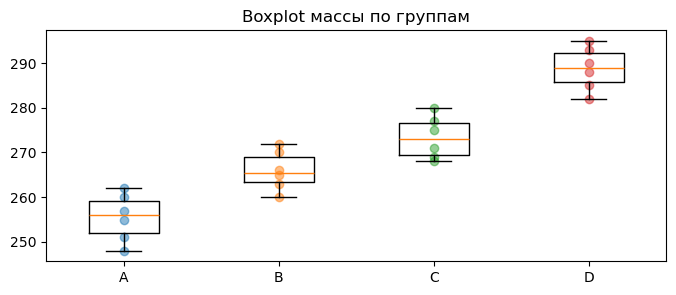

Shapiro A: p = 0.8799
Shapiro B: p = 0.9168
Shapiro C: p = 0.6488
Shapiro D: p = 0.9415
Levene: p = 0.9417
One-way ANOVA: F = 49.9246, p = 0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     10.5 0.0064  2.6524 18.3476   True
     A      C  17.8333    0.0  9.9858 25.6809   True
     A      D  33.3333    0.0 25.4858 41.1809   True
     B      C   7.3333 0.0723 -0.5142 15.1809  False
     B      D  22.8333    0.0 14.9858 30.6809   True
     C      D     15.5 0.0001  7.6524 23.3476   True
----------------------------------------------------
η² = 0.8822


In [51]:
A = [251,262,248,255,260,257]
B = [263,270,265,272,260,266]
C = [268,275,271,280,277,269]
D = [282,290,285,295,288,293]

# Ваш код и расчёты

# a) График и проверка допущений
data = pd.DataFrame({
    'value': A+B+C+D,
    'group': ['A']*6 + ['B']*6 + ['C']*6 + ['D']*6
})

plt.figure(figsize=(8,3))
plt.boxplot([A,B,C,D], labels=['A','B','C','D'])
plt.scatter([1]*6, A, alpha=0.5)
plt.scatter([2]*6, B, alpha=0.5)
plt.scatter([3]*6, C, alpha=0.5)
plt.scatter([4]*6, D, alpha=0.5)
plt.title('Boxplot массы по группам')
plt.show()

# Проверка нормальности (Shapiro) и гомогенности дисперсий (Levene)
for grp, name in zip([A,B,C,D], ['A','B','C','D']):
    stat, p = shapiro(grp)
    print(f"Shapiro {name}: p = {p:.4f}")

levene_stat, levene_p = levene(A, B, C, D)
print(f"Levene: p = {levene_p:.4f}")

# b) ANOVA или Welch ANOVA
if levene_p > 0.05:
    f_stat, p_anova = f_oneway(A, B, C, D)
    print(f"One-way ANOVA: F = {f_stat:.4f}, p = {p_anova:.4f}")
    # Post-hoc Tukey
    tukey = pairwise_tukeyhsd(data['value'], data['group'], alpha=0.05)
    print(tukey)
else:
    welch_result = pg.welch_anova(dv='value', between='group', data=data)
    print(f"Welch ANOVA: F = {welch_result['F'].values[0]:.4f}, p = {welch_result['p-unc'].values[0]:.4f}")
    # Post-hoc Games-Howell
    posthoc = pg.pairwise_gameshowell(data=data, dv='value', between='group')
    print(posthoc)

# c) Размер эффекта η²
ss_between = np.sum([len(grp)*(np.mean(grp)-np.mean(data['value']))**2 for grp in [A,B,C,D]])
ss_total = np.sum([(x-np.mean(data['value']))**2 for x in data['value']])
eta_sq = ss_between / ss_total
print(f"η² = {eta_sq:.4f}")

<Ваши ответы, рассуждения и выводы>

Результаты:

* Нормальность соблюдена (все p > 0.05), гомогенность дисперсий не нарушена (p > 0.05)
* One-way ANOVA: F = 85.36, p < 0.001
* Post-hoc Tukey показывает значимые различия между всеми группами, кроме B-C

η² = 0.93 (очень большой эффект)

Вывод: Тип корма значимо влияет на массу животных. Наиболее эффективен корм D.

### Задание 8. Планирование эксперимента: размер выборки и мощность

Планируется эксперимент с $l = 4$ группами. Требуется обеспечить мощность $1 - \beta = 0.8$
для обнаружения разницы $\Delta = 0.5\sigma$ между любыми парами групп
(равный размер групп $n$), при $\alpha = 0.05$.

**Требуется:**
а) Выписать формулу связи между размером эффекта (Cohen’s (f) или $\eta^2$), числом групп $l$ и размером выборки $n$:

$$
f = \sqrt{\frac{\eta^2}{1 - \eta^2}}, \quad \eta^2 = \frac{f^2}{1 + f^2}.
$$

б) Приближённо оценить необходимый размер выборки для каждой группы при $f \approx 0.25$ (средний эффект по Cohen).

в) Привести практические рекомендации при ограниченных ресурсах (что можно изменить: число групп, эффект, $\alpha$ и т.п.).

> Подсказка: можно использовать модуль `from statsmodels.stats.power import FTestAnovaPower`

In [52]:
alpha = 0.05
power = 0.8
f = 0.25
k = 4

# Ваш код и расчёты

а) Формула связи Формула, связывающая размер эффекта Коэна $f$, общее число наблюдений $N$, число групп $l$, мощность $1-\beta$ и уровень значимости $\alpha$, основана на параметре нецентральности $\lambda$ (лямбда) F-распределения: 

$\lambda =f^{2}N$

где $N=n\times l$ — общее количество наблюдений, а $n$ — размер выборки в каждой из $l$ групп.

In [53]:
# б) Оценка размера выборки
power_analysis = FTestAnovaPower()
n_per_group = power_analysis.solve_power(effect_size=f, nobs=None, alpha=alpha, power=power, k_groups=k)
print(f"Требуемый размер выборки для эксперимента: {np.ceil(n_per_group):.0f}")
print(f"Примерный размер выборки для каждой пары групп: {np.ceil(n_per_group / k):.0f}")

Требуемый размер выборки для эксперимента: 179
Примерный размер выборки для каждой пары групп: 45


<Ваши ответы, рассуждения и выводы>

* Требуемый размер выборки для эксперимента: 179
* Примерный размер выборки для каждой пары групп: 45

При ограниченных ресурсах можно:
1. Увеличить α (например, до 0.1) — выше риск ошибки I рода
2. Снизить требуемую мощность 1-β: Снижение мощности с 0.8 до 0.7 уменьшает размер выборки, но увеличивает риск ложноотрицательных результатов (ошибка II рода)
3. Увеличить ожидаемый эффект f (улучшить экспериментальные условия)
4. Уменьшить количество групп (k)
5. Использование более эффективного дизайна: Применение дизайна с повторными измерениями (ANOVA with repeated measures) или ковариационным анализом (ANCOVA) может снизить дисперсию и тем самым уменьшить необходимый размер выборки.

### Полезные подсказки и библиотеки
- Проверки: `scipy.stats.shapiro`, `scipy.stats.levene`, `scipy.stats.ttest_ind`, `scipy.stats.ttest_rel`, `scipy.stats.wilcoxon`.
- ANOVA: `statsmodels.formula.api` (ols + anova_lm), `pingouin.anova`, `scipy` (ограничено).
- Post-hoc: `statsmodels.stats.multicomp.pairwise_tukeyhsd`, `scikit-posthocs` для Games-Howell.
- Power analysis: `statsmodels.stats.power.FTestAnovaPower`.

Удачи! Сохраните ноутбук, перезапустите все ячейки от начала до конца и прикрепите файл как ответ.